# Notebook pour charger le jeu sur VS Code

In [2]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/prog_IceHockey

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/prog_IceHockey


In [3]:
import os
import torch
device = 'GPU' if torch.cuda.is_available() else 'CPU'
print('Vous utilisez le {} '.format(device))

Vous utilisez le GPU 


In [4]:
import gymnasium as gym
import ale_py

print(f"Version de ALE: {ale_py.__version__}")

game_list = [spec for spec in gym.registry.keys() if 'IceHockey' in spec]
print(f"Jeux d'arcade disponibles: {game_list}")

Version de ALE: 0.11.2
Jeux d'arcade disponibles: ['IceHockey-v0', 'IceHockey-v4', 'IceHockeyNoFrameskip-v0', 'IceHockeyNoFrameskip-v4', 'ALE/IceHockey-v5']


In [5]:
!pip install "pettingzoo[atari,accept-rom-license]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 552.0/552.0 kB 16.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.5/852.5 kB 53.4 MB/s eta 0:00:00
  Created wheel for multi_agent_ale_py: filename=multi_agent_ale_py-0.1.11-cp312-cp312-linux_x86_64.whl size=721822 sha256=ff6a80cae464ed37fa3bf8c90444c2c6946acce7b10a86393d4f589d2cfb27f0
  Stored in directory: /root/.cache/pip/wheels/e8/3a/b7/07e61057dae117a8c0943263e0e88e2fa71d95b285720ff9e1
Successfully built multi_agent_ale_py


In [6]:
! pip install "AutoROM[accept-rom-license]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.7/434.7 kB 12.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for AutoROM.accept-rom-license: filename=autorom_accept_rom_license-0.6.1-py3-none-any.whl size=446710 sha256=97297e0f23a21c87bc3c05182c1b8199fdde9187af575a7aed2063e081614213
  Stored in directory: /root/.cache/pip/wheels/99/f1/ff/c6966c034a8259164bdc9deb4d1ea839f119474638100e6645
Successfully built AutoROM.accept-rom-license


In [7]:
! AutoROM --accept-license

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms
	/usr/local/lib/python3.12/dist-packages/multi_agent_ale_py/roms

Existing ROMs will be overwritten.
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/adventure.bin
Installed /usr/local/lib/python3.12/dist-packages/multi_agent_ale_py/roms/adventure.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/air_raid.bin
Installed /usr/local/lib/python3.12/dist-packages/multi_agent_ale_py/roms/air_raid.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/alien.bin
Installed /usr/local/lib/python3.12/dist-packages/multi_agent_ale_py/roms/alien.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/amidar.bin
Installed /usr/local/lib/python3.12/dist-packages/multi_agent_ale_py/roms/amidar.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/assault.bin
Installed /usr/local/lib/python3.12/dist-packages/multi_

In [8]:
! pip install supersuit pettingzoo[atari]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 563.6/563.6 kB 22.2 MB/s eta 0:00:00


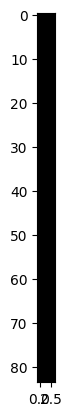

Forme finale de l'observation : (84, 84, 4)


In [13]:
import supersuit as ss
import matplotlib.pyplot as plt
from pettingzoo.atari import ice_hockey_v2

def get_env():
    # 1. Env de base
    env = ice_hockey_v2.env(render_mode="rgb_array")

    # 2. Réduction à 1 seul canal (Rouge) -> (210, 160, 1)
    env = ss.color_reduction_v0(env, mode='R')

    # 3. Redimensionnement -> (84, 84, 1)
    env = ss.resize_v1(env, x_size=84, y_size=84)

    # 4. On empile 4 images -> (84, 336, 1) ou (1, 84, 336) selon ta version
    env = ss.frame_stack_v1(env, 4)

    # 5. On convertit en float32
    env = ss.dtype_v0(env, 'float32')

    return env
# --- TEST DE VÉRIFICATION ---
env = get_env()
env.reset()
obs, reward, term, trunc, info = env.last()
plt.imshow(obs[0], cmap='gray')
plt.show()
print(f"Forme finale de l'observation : {obs.shape}")

In [17]:
import torch
import numpy as np
from pettingzoo.atari import ice_hockey_v2
from MAPOCA.actor import MultiAgentActors


# 1. Utilise ta fonction get_env() pour avoir les wrappers SuperSuit
env = get_env()
# Note : Si tu veux voir le jeu, change render_mode="human" dans get_env
# ou utilise render_mode="rgb_array" pour Colab.

env.reset()

max_steps = 5000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

actor = MultiAgentActors(action_dim=18).to(device)

# On suppose que 'actor' est déjà initialisé et envoyé sur le device
actor.eval() # Mode évaluation

for i, agent in enumerate(env.agent_iter()):
    observation, reward, termination, truncation, info = env.last()

    if termination or truncation:
        action = None
    else:
        # --- AJUSTEMENT DES DIMENSIONS ---
        # observation est (84, 84, 4) -> on veut (4, 84, 84)
        obs_input = observation.transpose(2, 0, 1)

        # Conversion en tenseur [1, 4, 84, 84]
        obs_tensor = torch.from_numpy(obs_input).float().unsqueeze(0).to(device)

        with torch.no_grad():
            # Utilise get_action pour avoir une décision (déterministe pour la démo)
            action = actor.get_action(obs_tensor, deterministic=True).item()

    env.step(action)

    if i >= max_steps:
        print(f"Arrêt manuel après {max_steps} itérations.")
        break

env.close()
print("Démo terminée proprement !")

Arrêt manuel après 5000 itérations.
Démo terminée proprement !


In [ ]:
ls

download_game.ipynb  MAPOCA/  README.md  VDN/


# Exécution de MA-POCA

In [14]:
# importation des bibliothèques et des classes nécessaires

from MAPOCA.multi_agent_buffer import MultiAgentBuffer

buffer = MultiAgentBuffer()


In [24]:
import torch

def collect_trajectories(env, actor, buffer, max_steps=1000):

    "Cette fonction permet de récupérer les trajectoires des agents pendant les mille premières étapes du jeu"
    env.reset()

    # Initialisation des stockages temporaires par agent
    temp_obs = {}
    temp_acts = {}
    temp_logprobs = {}

    step_count = 0

    for agent in env.agent_iter():
        # 'info' est ignoré car non nécessaire pour la logique MA-POCA de base
        obs, reward, terminated, truncated, _ = env.last()
        done = terminated or truncated

        if done:
            action = None
            logp = 0
        else:
            # Conversion de l'observation (H, W, C) -> (1, C, H, W) pour le CNN
            # Note: Vérifie si ton Wrapper Supersuit a déjà mis les channels en premier
            obs_permu = obs.transpose(2, 0, 1)
            obs_tensor = torch.from_numpy(obs_permu).float().unsqueeze(0).to(device)

            with torch.no_grad():
                logits = actor(obs_tensor)
                dist = torch.distributions.Categorical(logits=logits)
                action_tensor = dist.sample()
                logp = dist.log_prob(action_tensor).item()
                action = action_tensor.item()

        env.step(action)

        # 1. Stockage de l'observation de l'agent actuel
        temp_obs[agent] = obs

        # 2. Stockage de l'action si le jeu n'est pas fini
        if action is not None:
            temp_acts[agent] = action
            temp_logprobs[agent] = logp

        # 3. Une fois que les DEUX agents ont agi (Fin du cycle temporel t)
        if len(temp_acts) == 2:
            # On récupère le dictionnaire complet des récompenses du pas t
            # 'env.rewards' contient {'first_0': r1, 'second_0': r2}
            current_rewards = [env.rewards['first_0'], env.rewards['second_0']]

            buffer.add(
                observation=[temp_obs['first_0'], temp_obs['second_0']],
                action=[temp_acts['first_0'], temp_acts['second_0']],
                logprob=[temp_logprobs['first_0'], temp_logprobs['second_0']],
                reward=current_rewards,
                done=done
            )

            # Reset des dictionnaires temporaires pour le prochain pas t+1
            temp_acts = {}
            temp_logprobs = {}
            step_count += 1

        if done or step_count >= max_steps:
            break

    return step_count

In [30]:
def compute_returns_lambda(rewards, values, next_value, dones, gamma=0.99, lmbda = 0.95):
    "Calcule G_t^(lambda) pour un agent"

    returns = torch.zeros_like(rewards)
    gae = 0

    for t in reversed(range(len(rewards))):
        if t == len(rewards) -1:
            next_non_terminal = 1.0 - dones[t]
            next_val = next_value
        else:
            next_non_terminal = 1.0 - dones[t+1]
            next_val = values[t+1]

        # TD Error (delta)
        delta = rewards[t] + gamma * next_val * next_non_terminal - values[t]

        # GAE (Generalized Advantage Estimation) qui est équivalent au TD(lambda)
        gae = delta + gamma * lmbda * next_non_terminal * gae

        returns[t] = gae + values[t]

    return returns


In [31]:
def prepare_targets(buffer, critic, gamma=0.99, lmbda = 0.95):
    obs_ag1 = torch.stack([torch.from_numpy(o[0]) for o in buffer.observations]).float()
    obs_ag2 = torch.stack([torch.from_numpy(o[1]) for o in buffer.observations]).float()

    rewards = torch.tensor(buffer.rewards).float()  # Shape: (N, 2)
    dones = torch.tensor(buffer.dones).float()      # Shape: (N,)

    #2. ici on cherche à obtenir les valeurs V du critic centralisé

    with torch.no_grad():
        values = critic([obs_ag1, obs_ag2])  # Shape: (N, 2)

        next_value = torch.zeros(2)

    all_returns = []
    all_advantages = []
    for i in range(2):
        ret = compute_returns_lambda(
            rewards[:, i], values[:, i], next_value[i], dones, gamma, lmbda
        )
        advantage = ret - values[:, i]
        all_returns.append(ret)
        all_advantages.append(advantage)


    return torch.stack(all_returns, dim=1), torch.stack(all_advantages, dim=1)

In [32]:
def update_mapoca(actor, critic, buffer, optimizer_actor, optimizer_critic):
    #1. Préparation des données

    returns, advantages = prepare_targets(buffer, critic)

    #2. on applatit ensuite les dimensions pour le calcul de la perte

    obs_ag1 = torch.stack([torch.from_numpy(o[0]) for o in buffer.observations]).float()
    obs_ag2 = torch.stack([torch.from_numpy(o[1]) for o in buffer.observations]).float()
    actions = torch.tensor(buffer.actions)  # Shape: (N, 2)
    old_logprobs = torch.tensor(buffer.logprobs)  # Shape: (N, 2)

    #3. Mise à jour du critic centralisé

    current_values = critic([obs_ag1, obs_ag2])  # Shape: (N, 2)
    critic_loss = torch.nn.MSELoss()(current_values, returns)

    # 4. Mise à jour de l'actor

    # pour l'agent 1
    logits1 = actor(obs_ag1)  # Shape: (N, action_dim)
    dist1 = torch.distributions.Categorical(logits=logits1)
    new_logprob1 = dist1.log_prob(actions[:, 0])  # Log-prob de l'action prise par agent 1

    # pour l'agent 2

    logits2 = actor(obs_ag2)  # Shape: (N, action_dim)
    dist2 = torch.distributions.Categorical(logits=logits2)
    new_logprob2 = dist2.log_prob(actions[:, 1])  # Log-prob de l'action prise par agent 2

    # Calcul de la perte Policy Gradient pour les deux agents

    actor_loss = -(new_logprob1 * advantages[:, 0]).mean() - (new_logprob2 * advantages[:, 1]).mean()

    # Ajout de l'entropie pour encourager l'exploration

    entropy = dist1.entropy().mean() + dist2.entropy().mean()
    total_actor_loss = actor_loss - 0.01 * entropy

    optimizer_actor.zero_grad()
    total_actor_loss.backward()
    optimizer_actor.step()

    return critic_loss.item(), actor_loss.item()



## Exécution de la boucle principale

100%|██████████| 1000/1000 [18:28<00:00,  1.11s/it]


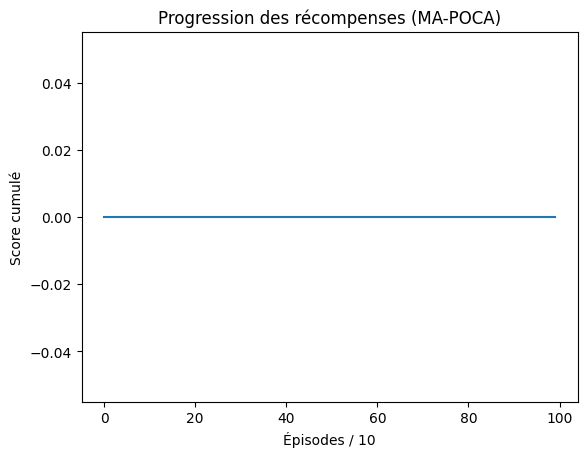

In [33]:
#importation des bibliothèques

import torch
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# importation des modules

from MAPOCA.multi_agent_buffer import MultiAgentBuffer
from MAPOCA.centralized_critic import Centralized_critic
from MAPOCA.actor import MultiAgentActors
from MAPOCA.observation_encoding import Impala_CNN, Impala_Layer
from MAPOCA.RSA import RSAModule

# Hyperparamètres
LR_ACTOR = 1e-4
LR_CRITIC = 3e-4
GAMMA = 0.99
LMBDA = 0.95
BATCH_SIZE = 128  # Nombre de pas de temps par mise à jour
TOTAL_EPISODES = 1000

actor = MultiAgentActors(action_dim = 18).to(device)
critic = Centralized_critic(num_agents=2).to(device)

optimizer_actor = optim.Adam(actor.parameters(), lr=LR_ACTOR)
optimizer_critic = optim.Adam(critic.parameters(), lr=LR_CRITIC)

buffer = MultiAgentBuffer()

# Boucle principale

rewards_history = []

for episode in tqdm(range(TOTAL_EPISODES)):

  step_count = collect_trajectories(env, actor, buffer, max_steps=BATCH_SIZE)

  if len(buffer.observations) >= BATCH_SIZE:
        # 1. On transforme les listes en tenseurs [Batch, H, W, C]
        obs_raw_1 = torch.stack([torch.from_numpy(o[0]) for o in buffer.observations]).float()
        obs_raw_2 = torch.stack([torch.from_numpy(o[1]) for o in buffer.observations]).float()

        # 2. LE FIX CRUCIAL : On permute les dimensions pour passer en [Batch, C, H, W]
        # (0: Batch, 1: H, 2: W, 3: C) -> on veut (0, 3, 1, 2)
        obs_ag1 = obs_raw_1.permute(0, 3, 1, 2).to(device)
        obs_ag2 = obs_raw_2.permute(0, 3, 1, 2).to(device)

        # Reste de la préparation
        rewards = torch.tensor(buffer.rewards).float().to(device)
        dones = torch.tensor(buffer.dones).float().to(device)
        actions = torch.tensor(buffer.actions).to(device)
        # Calcul des valeurs V et returns

        with torch.no_grad():
            values = critic([obs_ag1, obs_ag2])
            next_value = torch.zeros(2).to(device)

        all_returns = []
        for i in range(2):
          ret = compute_returns_lambda(rewards[:, i], values[:, i], next_value[i], dones, GAMMA, LMBDA)
          all_returns.append(ret)

        returns = torch.stack(all_returns, dim=1)
        advantages = returns - values

        # Mise à jour du critic

        current_values = critic([obs_ag1, obs_ag2])
        critic_loss = F.mse_loss(current_values, returns)

        optimizer_critic.zero_grad()
        critic_loss.backward()
        optimizer_critic.step()

        # Mise à jour de l'actor

        # Agent 1

        logits1 = actor(obs_ag1)
        dist1 = torch.distributions.Categorical(logits=logits1)
        logp1 = dist1.log_prob(actions[:, 0])

        # Agent 2
        logits2 = actor(obs_ag2)
        dist2 = torch.distributions.Categorical(logits=logits2)
        logp2 = dist2.log_prob(actions[:, 1])

        # Loss : on maximise (log_prob * advantage) -> on minimise -(log_prob * advantage)
        actor_loss = -(logp1 * advantages[:, 0]).mean() - (logp2 * advantages[:, 1]).mean()

        optimizer_actor.zero_grad()
        actor_loss.backward()
        optimizer_actor.step()

        buffer.clear()

  if episode % 10 == 0:
    rewards_history.append(rewards.sum().item())

#Visualisation

plt.plot(rewards_history)
plt.title("Progression des récompenses (MA-POCA)")
plt.xlabel("Épisodes / 10")
plt.ylabel("Score cumulé")
plt.show()

